# 1. Problem Statement

The objective of this project is to develop a Machine Learning model that can accurately classify objects detected by sonar signals as either 
Rock or Mine. Sonar systems transmit sound waves underwater, and the reflected signals vary depending on the type of object they hit.By 
analyzing these reflected sonar signal patterns, the model learns to distinguish between rocks and underwater mines. This classification helps 
improve the accuracy and efficiency of underwater object detection while reducing manual effort and human error.

# 2. Dataset Information

In [ ]:
The dataset contains 208 records (instances).
It has 61 columns, including 60 input features and 1 target column.
The 60 input features represent the energy values of sonar signals reflected from underwater objects.
The target column contains the class label of each object.
The dataset has two classes: Rock (R) and Mine (M).
All input features are continuous numerical values ranging from 0.0 to 1.0.
This is a supervised machine learning dataset because the correct class labels are already provided.
It is a binary classification problem since there are only two output classes.
The dataset is available in CSV (tabular) format.
The dataset does not contain missing values.
The original dataset does not contain duplicate records.
This dataset is used to train and test a machine learning model to classify underwater objects as either Rock or Mine based on sonar
signal data.

# Importing the Dependencies

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import os

In [38]:
import os

print(os.getcwd())

D:\Anju\SONAR Dataset\archive (1)


In [5]:
import os
os.listdir()

['.ipynb_checkpoints',
 'SONAR Rock vs Mine Prediction with python.ipynb',
 'sonar_data.csv',
 'Untitled.ipynb']

In [6]:
df = pd.read_csv("sonar_data.csv", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [7]:
print(os.getcwd())

D:\Anju\SONAR Dataset\archive (1)


# 3. Data Collection and Data Processing

In [8]:
df = pd.read_csv(r"D:\Anju\SONAR Dataset\archive (1)\sonar_data.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [9]:
# removes uplicates value
df.duplicated().sum()

np.int64(0)

In [11]:
# Corresct data types
df.dtypes

0     float64
1     float64
2     float64
3     float64
4     float64
       ...   
56    float64
57    float64
58    float64
59    float64
60     object
Length: 61, dtype: object

In [10]:
# numbers of rows and columns
df.shape

(208, 61)

In [55]:
df.describe      # describe --> statistical measure of the data

<bound method NDFrame.describe of          0       1       2       3       4       5       6       7       8   \
0    0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1    0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2    0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3    0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4    0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   
204  0.0323  0.0101  0.0298  0.0564  0.0760  0.0958  0.0990  0.1018  0.1030   
205  0.0522  0.0437  0.0180  0.0292  0.0351  0.1171  0.1257  0.1178  0.1258   
206  0.0303  0.0353  0.0490  0.0608  0.0167  0.1354  0.1465  0.1123  0.1945   
207  0.0260  0.0363  0.0136  0.0272  0.0214  0.0338  0.0655  0.1400  0.1843   

         9   ... 

In [73]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

##  4. M --> Mine
##  R --> Rock

In [34]:
df.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


In [20]:
# Separating Features and Target

X = df.drop(columns=60, axis=1)
Y = df[60]

In [21]:
print(X)
print(Y)

         0       1       2       3       4       5       6       7       8   \
0    0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1    0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2    0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3    0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4    0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   
204  0.0323  0.0101  0.0298  0.0564  0.0760  0.0958  0.0990  0.1018  0.1030   
205  0.0522  0.0437  0.0180  0.0292  0.0351  0.1171  0.1257  0.1178  0.1258   
206  0.0303  0.0353  0.0490  0.0608  0.0167  0.1354  0.1465  0.1123  0.1945   
207  0.0260  0.0363  0.0136  0.0272  0.0214  0.0338  0.0655  0.1400  0.1843   

         9   ...      50      51      52      53   

## 4. Traning and Testing data

In [35]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size = 0.1, stratify = Y, random_state = 1)

In [23]:
print(X.shape, X_train.shape, X_test.shape)

(208, 60) (187, 60) (21, 60)


## 5. Model Traning --> Logistic Regression

In [24]:
model = LogisticRegression()

In [25]:
# traning the logistic regression model with train data
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# 6. Exploratory Data Analysis (EDA)

## i) Count Plot

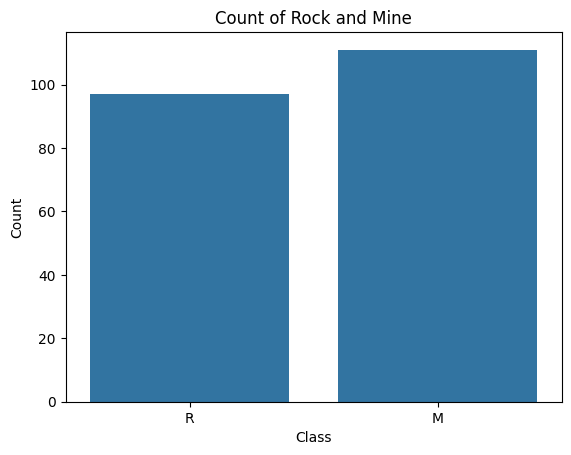

In [26]:
# Count Plot of Target Variable

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df[60])

plt.title("Count of Rock and Mine")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## ii) Bar plot

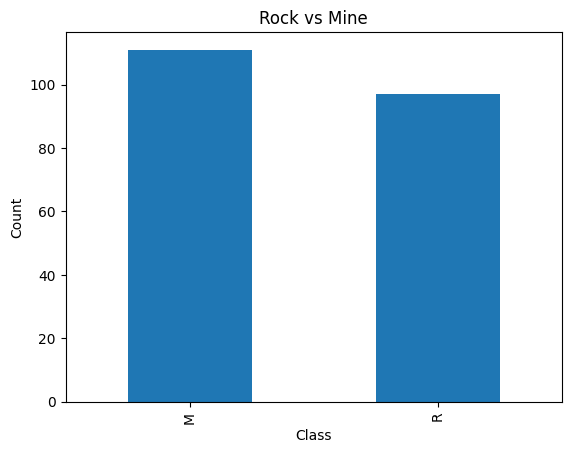

In [27]:
# Import Libraries
import matplotlib.pyplot as plt

# Count Rock (R) and Mine (M)
df[60].value_counts().plot(kind='bar')

# Title and Labels
plt.title("Rock vs Mine")
plt.xlabel("Class")
plt.ylabel("Count")

# Show Plot
plt.show()

## iii) Correction Heatmap

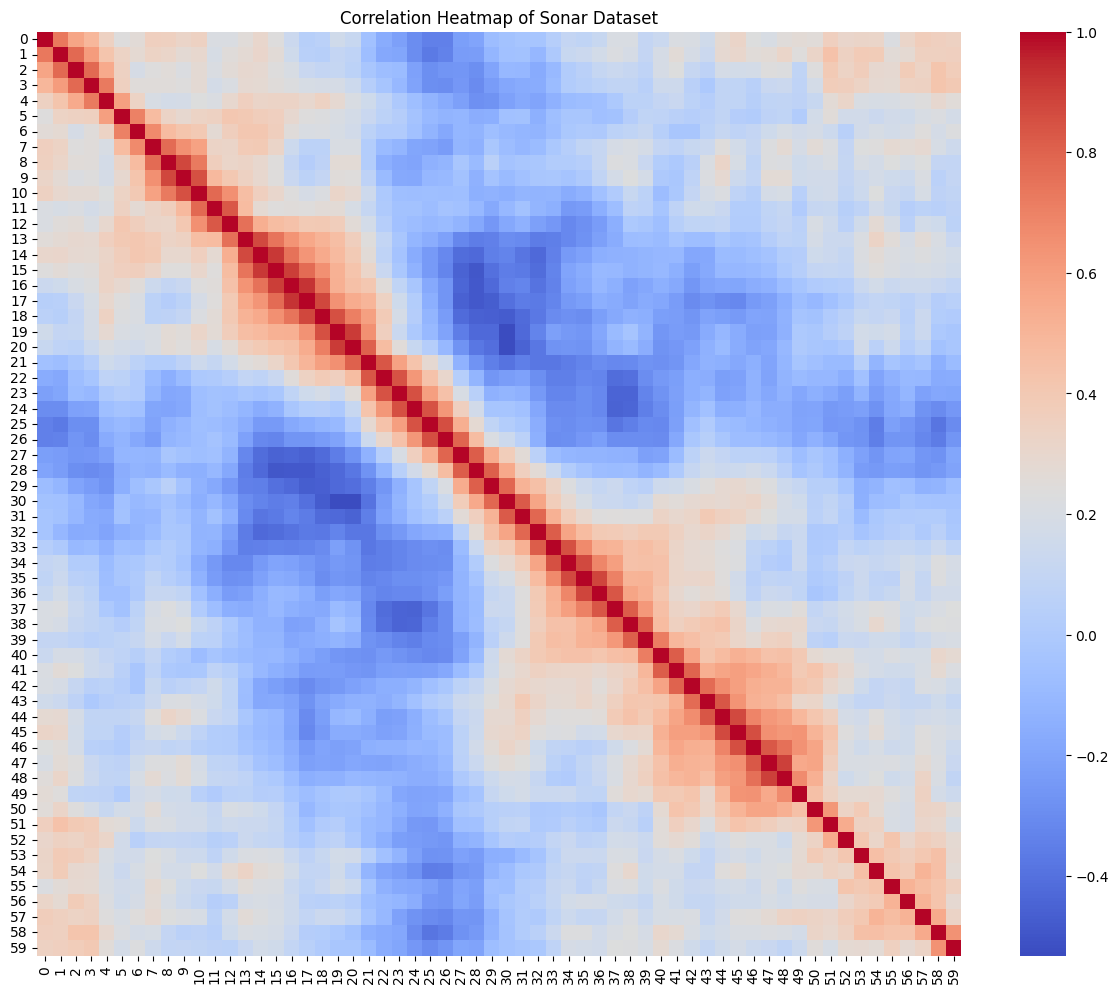

In [28]:
# Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Correlation Matrix
correlation = df.corr(numeric_only=True)

# Plot Heatmap
plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    annot=False,
    cbar=True,
    square=True
)

# Title
plt.title("Correlation Heatmap of Sonar Dataset")

# Show Plot
plt.show()

## 7. Model Evalution

In [29]:
# accuracy on training data
X_train_prediction = model.predict(X_train)

training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [30]:
print("Accuracy on training data:", training_data_accuracy)

Accuracy on training data: 0.8342245989304813


## 8. Making a Predictive System

In [31]:
input_data = (0.1150,0.1163,0.0866,0.0358,0.0232,0.1267,0.2417,0.2661,0.4346,0.5378,0.3816,0.0991,0.0616,0.1795,0.3907,0.3602,0.3041,0.2428,0.4060,0.8395,0.9777,0.4680,0.0610,0.2143,0.1348,0.2854,0.1617,0.2649,0.4565,0.6502,0.2848,0.3296,0.5370,0.6627,0.8626,0.8547,0.7848,0.9016,0.8827,0.6086,0.2810,0.0906,0.1177,0.2694,0.5214,0.4232,0.2340,0.1928,0.1092,0.0507,0.0228,0.0099,0.0065,0.0085,0.0166,0.0110,0.0190,0.0141,0.0068,0.0086)
# changing the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

In [32]:
# reshape the np array as we are predictiona for one instance
input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = model.predict(input_data_reshaped)

print(prediction)

if prediction[0] == 'R':
    print("The object is Mine")
else:
    print("The object is Mine")

['M']
The object is Mine


# 9. Model Building

In [33]:

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Model
model = LogisticRegression()

# Train the Model
model.fit(X_train, Y_train)

print("Model Trained Successfully")

Model Trained Successfully


# 10. Conclusion

This project successfully developed a Machine Learning model to classify underwater objects as Rock (R) or Mine (M) using the Sonar Dataset. The
dataset was preprocessed, divided into training and testing sets, and a Logistic Regression model was trained. The model achieved good accuracy
in predicting whether the object is a rock or a mine based on sonar signal features. This project demonstrates how machine learning can be 
applied to solve real-world classification problems and highlights the importance of data preprocessing, model training, and performance
evaluation in building reliable predictive systems.